This file will give the structure to build entirelyh a district heating network from a graph-representation. 

The physical connection of the entire district heating and cooling networks is described by a incidence matrix. Each node represent one element of a the district heating. 

For each element linked in the graph, there is a pair od pipes. One named high pressure line and the other low pressure line. The incidence matrix will described only the high pressure and the low pressure is that matrix *-1. 

There is going to be the option to build a a network from the shp file or from a incidence matrix. 



In [85]:
import networkx as nx
import pandas as pd
import numpy as np
import pandapipes
from IPython.display import Image
import pandapipes as pp 
from External_objects_functions import Bidirectional_W_to_WHeatPump,ThermoclineTwoLayer,ConsumerActor,Slack_Central_production,Central_production,Pipe_class
import random
import time

In [86]:
class ConvergenceError(Exception):
    """El bucle iterativo de temperaturas no convergió."""
    pass

In [ ]:
class DHN ():
    "This class will deal with the mathematical graph structure , the construction of the network in pandapipes and the instantiate of the "
    "external objects "
    def __init__(self,type_Graph,layout):
        self.type_Graph=type_Graph
        self.layout=layout
    def Graph_From_Excel(self,excel_path,sheet=0,Node_Column=0,Edge_row=0): 
        """This function will create a graph representation from a incidenct matrix coming from an excel descrption"""
        Sheet_1=pd.read_excel(excel_path,sheet)
        Sheet_2=pd.read_excel(excel_path,sheet+1)
        Sheet_3=pd.read_excel(excel_path,sheet+2)
        Sheet_4=pd.read_excel(excel_path,sheet+3)
        Sheet_5=pd.read_excel(excel_path,sheet+4)
        Sheet_6=pd.read_excel(excel_path,sheet+5)
        Sheet_7=pd.read_excel(excel_path,sheet+6)
        Sheet_8=pd.read_excel(excel_path,sheet+7)
        # Graph characteristics
        self.Nodes=Sheet_1.iloc[:,Node_Column].tolist()
        self.Edges=list(Sheet_1.columns.values[1:])
        self.Type_Nodes=Sheet_2.iloc[0,1:].tolist()
        self.IM=Sheet_1.iloc[:,Node_Column+1:].to_numpy()
        #Pipe characteristics
        self.Pipes_charact=Sheet_3.iloc[:,Node_Column+1:]
        if self.Pipes_charact.empty: 
            pass
        else:
            lengths=self.Pipes_charact.iloc[0, :].tolist()
            inner_diameters=self.Pipes_charact.iloc[1, :].tolist()
            u_w_per_m2k=self.Pipes_charact.iloc[2, :].tolist()
            K_mm=self.Pipes_charact.iloc[3, :].tolist()
        #Central plant characteristics 
        self.central_plant_characteristicst={"node":[],"Fuel_type":[],"Nominal_efficiency":[],"Emission_factor":[],"cost_constant":[],'T_out_design':[],'P_out_design':[],'P_lift_design':[]}
        self.central_plant_characteristicst_excel=Sheet_5.iloc[:,Node_Column+1:]
        self.central_plant_characteristicst["node"]=self.central_plant_characteristicst_excel.columns.tolist()
        self.central_plant_characteristicst["Fuel_type"]=self.central_plant_characteristicst_excel.iloc[0,:].tolist()
        self.central_plant_characteristicst["Nominal_efficiency"]=self.central_plant_characteristicst_excel.iloc[1, :].tolist()
        self.central_plant_characteristicst["Emission_factor"]=self.central_plant_characteristicst_excel.iloc[2, :].tolist()
        self.central_plant_characteristicst["cost_constant"]=self.central_plant_characteristicst_excel.iloc[3, :].tolist()
        self.central_plant_characteristicst["T_out_design"]=self.central_plant_characteristicst_excel.iloc[4, :].tolist()
        self.central_plant_characteristicst["P_out_design"]=self.central_plant_characteristicst_excel.iloc[5, :].tolist()
        self.central_plant_characteristicst["P_lift_design"]=self.central_plant_characteristicst_excel.iloc[6, :].tolist()

        #Storage characteristics
        self.Storage_characteristics={"node":[],"V_tot":[],"T_hot_init":[],"T_cold_init":[],"v_hot_fraction":[],"UA_loss":[],"UA_interface":[]}
        self.Storage_characteristics_excel=Sheet_4.iloc[:,Node_Column+1:]
        if self.Storage_characteristics_excel.empty:
            pass
        else:
            self.Storage_characteristics["node"]=self.Storage_characteristics_excel.columns.tolist()
            self.Storage_characteristics["V_tot"]=self.Storage_characteristics_excel.iloc[0,:].tolist()
            self.Storage_characteristics["T_hot_init"]=self.Storage_characteristics_excel.iloc[1, :].tolist()
            self.Storage_characteristics["T_cold_init"]=self.Storage_characteristics_excel.iloc[2, :].tolist()
            self.Storage_characteristics["v_hot_fraction"]=self.Storage_characteristics_excel.iloc[3, :].tolist()
            self.Storage_characteristics["UA_loss"]=self.Storage_characteristics_excel.iloc[4, :].tolist()
            self.Storage_characteristics["UA_interface"]=self.Storage_characteristics_excel.iloc[5, :].tolist()
        #HP characteristics 
        self.HP_characteristics={"node":[],"refrigerant ":[],"dT_water":[],"eta_s":[]}
        self.HP_characteristics_excel=Sheet_6.iloc[:,Node_Column+1:]
        if  self.HP_characteristics_excel.empty:
            pass
        else:
            self.HP_characteristics["node"]=self.HP_characteristics_excel.columns.tolist()
            self.HP_characteristics["refrigerant"]=self.HP_characteristics_excel.iloc[0,:].tolist()
            self.HP_characteristics["dT_water"]=self.HP_characteristics_excel.iloc[1, :].tolist()
            self.HP_characteristics["eta_s"]=self.HP_characteristics_excel.iloc[2, :].tolist()
        #Plant_support characteristics 
        self.plant_support_charateristics={"node":[],"Fuel_type":[],"Nominal_efficiency ":[],"Emission_factor":[],"cost_constant":[],'T_out_design':[]}
        self.plant_support_charateristics_excel=Sheet_7.iloc[:,Node_Column+1:]
        if self.plant_support_charateristics_excel.empty:
            pass
        else:
            self.plant_support_charateristics["node"]=self.plant_support_charateristics_excel.columns.tolist()
            self.plant_support_charateristics["Fuel_type"]=self.plant_support_charateristics_excel.iloc[0,:].tolist()
            self.plant_support_charateristics["Nominal_efficiency"]=self.plant_support_charateristics_excel.iloc[1,:].tolist()
            self.plant_support_charateristics["Emission_factor"]=self.plant_support_charateristics_excel.iloc[2, :].tolist()
            self.plant_support_charateristics["cost_constant"]=self.plant_support_charateristics_excel.iloc[3, :].tolist()
            self.plant_support_charateristics["T_out_design"]=self.plant_support_charateristics_excel.iloc[4, :].tolist()

        #Heat_consumer characteristics
        self.heat_consumer_charateristics={"node":[],"T_return":[]}
        self.heat_consumer_charateristics_excel=Sheet_8.iloc[:,Node_Column+1:]
        self.heat_consumer_charateristics["node"]=self.heat_consumer_charateristics_excel.columns.tolist()
        self.heat_consumer_charateristics["T_return"]=self.heat_consumer_charateristics_excel.iloc[0,:].tolist()


        if self.type_Graph== "Undirected":
            self.graph=nx.Graph()
            for i in range(len(self.Nodes)):
                self.graph.add_node(self.Nodes[i],type=self.Type_Nodes[i])
            edges=[]
            for i in range(self.IM.shape[1]): 
                list_nodes=[]
                col=self.IM[:,i]
                for j in range (self.IM.shape[0]): 
                    if col[j] == 1:
                        list_nodes.append(self.Nodes[j])
                edges.append((list_nodes[0],list_nodes[1],{"length": lengths[i],"name":self.Edges[i],'inner_diameter':inner_diameters[i],'u_w_per_m2k':u_w_per_m2k[i],'K_mm:':K_mm[i]}))
        elif self.type_Graph== "Directed":
            self.graph=nx.DiGraph()
            for i in range(len(self.Nodes)):
                self.graph.add_node(self.Nodes[i],type=self.Type_Nodes[i])
            edges=[]
            for i in range(self.IM.shape[1]): 
                list_nodes=[]
                col=self.IM[:,i]
                tails=int(np.where(col == 1)[0][0])
                heads=int(np.where(col == -1)[0][0])
                edges.append((self.Nodes[tails],self.Nodes[heads],{"length": lengths[i],"name":self.Edges[i],'inner_diameter':inner_diameters[i],'u_w_per_m2k':u_w_per_m2k[i],'K_mm:':K_mm[i]}))
        self.graph.add_edges_from(edges)
        self.draw_graph_graphviz_from_excel()

    def graph_from_SHP(self,shp_path):
        """This function will create a graph from a shp file"""
        pass
    

    def create_pandapipes_plus_initialization(self,fluid="water"):
        self.net=pp.create_empty_network(fluid=fluid)
        # Creation of pairs of nodes
        for i in range(len(self.Nodes)):
            if self.Type_Nodes[i]=="Storage":
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_highp')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_inter_1')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_inter_2')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_lowp')

            elif self.Type_Nodes[i]=="Plant_support":
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_highp')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_inter')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_lowp')
            else:
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_highp')
                pp.create_junction(self.net,pn_bar=5,tfluid_k=353.15, name=self.Nodes[i] + '_lowp')
        #Creation of pipes 
        for u, v in self.graph.edges():
            name=self.graph.edges[u, v].get("name", "")
            length=self.graph.edges[u, v].get("length", 1)
            inner_diameters=self.graph.edges[u, v].get("inner_diameter", 1)
            u_w_per_m2k=self.graph.edges[u, v].get("u_w_per_m2k", 1)
            K_mm=self.graph.edges[u, v].get("K_mm", 0.1)
            pp.create_pipe_from_parameters(self.net, from_junction=self.net.junction[self.net.junction["name"]==u+ '_highp'].index[0], 
                                           to_junction=self.net.junction[self.net.junction["name"]==v+ '_highp'].index[0],length_km=length, 
                                           inner_diameter_mm=inner_diameters, u_w_per_m2k=u_w_per_m2k, name=name+"_supply",k_mm=K_mm,text_k=283.15)
            pp.create_pipe_from_parameters(self.net, from_junction=self.net.junction[self.net.junction["name"]==v+ '_lowp'].index[0], 
                                           to_junction=self.net.junction[self.net.junction["name"]==u+ '_lowp'].index[0],length_km=length
                                           , inner_diameter_mm=inner_diameters, u_w_per_m2k=u_w_per_m2k, name=name+"_return",k_mm=K_mm,text_k=283.15)

        #Creation of elements in pandapipes and elements
        for i in range(len(self.Nodes)):
            if self.Type_Nodes[i]=="Storage":
                #Charging part
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0], 
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_1'].index[0],
                    controlled_mdot_kg_per_s=0.1,name="Flow_control_charge__input_Storage_"+self.Nodes[i])
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_1'].index[0], 
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                    controlled_mdot_kg_per_s=0.1,name="Flow_control_bypass_charge_Storage_"+self.Nodes[i])
                pp.create_circ_pump_const_mass_flow(
                    self.net, return_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_1'].index[0],
                    flow_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_2'].index[0],
                    mdot_flow_kg_per_s=0.1, t_flow_k=300, p_flow_bar=5 ,name="Circ_pump_charge_Storage_"+ self.Nodes[i])
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_2'].index[0],
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0],
                    controlled_mdot_kg_per_s=0.1,name="Flow_control_charge_output_Storage_"+ self.Nodes[i])
                #discharging part 
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0], 
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_2'].index[0],
                    controlled_mdot_kg_per_s=0.1, name="Flow_control_discharge_input_Storage_"+ self.Nodes[i])
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_2'].index[0], 
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0],
                    controlled_mdot_kg_per_s=0.1,name="Flow_control_bypass_discharge_Storage"+ self.Nodes[i])
                pp.create_circ_pump_const_mass_flow(
                    self.net, return_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_2'].index[0], 
                    flow_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_1'].index[0],
                    mdot_flow_kg_per_s=0.1, t_flow_k=300, p_flow_bar=5 ,name="Circ_pump_discharge_Storage_"+ self.Nodes[i])
                pp.create_flow_control(
                    self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter_1'].index[0], 
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                    controlled_mdot_kg_per_s=0.1,name="Flow_control_discharge_output_Storage"+ self.Nodes[i])
            elif self.Type_Nodes[i]=="Plant_support":
                pp.create_circ_pump_const_mass_flow(
                    self.net, return_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0], 
                    flow_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter'].index[0],
                    mdot_flow_kg_per_s=0.5, t_flow_k=0.5, p_flow_bar=2.5,name="Plant_support_circ_pump_"+self.Nodes[i])
                pp.create_flow_control(self.net, from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_inter'].index[0], 
                                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                                    controlled_mdot_kg_per_s=0.1,name="Flow_control_support_plant"+ self.Nodes[i])

            elif self.Type_Nodes[i]=="Plant":
                pp.create_circ_pump_const_pressure(
                                    self.net,flow_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                                    return_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0],
                                    p_flow_bar=5,plift_bar=5,t_flow_k=333 ,name='Central_plant')

            elif self.Type_Nodes[i]=="Prosumer":
                pp.create_heat_consumer(
                                    self.net,from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0],
                                    qext_w=150000,deltat_k=10,name=self.Nodes[i]+ "_Prosumer")

            elif self.Type_Nodes[i]=="Consumer":
                pp.create_heat_consumer(
                    self.net,from_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_highp'].index[0],
                    to_junction=self.net.junction[self.net.junction["name"]==self.Nodes[i] + '_lowp'].index[0],
                    qext_w=150000,treturn_k=305,name=self.Nodes[i]+ "_Consumer")

    def Creation_objects(self):
        self.Pipe_objects={"name":[],"Object":[]}
        self.Consumer_actors={"Node":[],"name":[],"Object":[]}
        self.slack_plant={"Node":0,"name":0,"Object":0}
        self.HP_actors={"Node":[],"name":[],"Object":[]}
        self.Storage_actors={"Node":[],"name":[],"Object":[]}
        self.multi_plant_actors={"Node":[],"name":[],"Object":[]}
        for i in range(len(self.Nodes)):
            if self.Type_Nodes[i]=="Storage":
                Storage=ThermoclineTwoLayer(net=self.net,name="Storage_"+ self.Nodes[i],
                                            fc_charge=self.net.flow_control[self.net.flow_control["name"]=="Flow_control_charge__input_Storage_"+self.Nodes[i]].index[0],
                                            fc_bypass_charge=self.net.flow_control[self.net.flow_control["name"]=="Flow_control_bypass_charge_Storage_"+ self.Nodes[i]].index[0],
                                            cp_charge_storage=self.net.circ_pump_mass[self.net.circ_pump_mass["name"]=="Circ_pump_charge_Storage_"+ self.Nodes[i]].index[0],
                                            fc_charge_storage=self.net.flow_control[self.net.flow_control["name"]=="Flow_control_charge_output_Storage_"+ self.Nodes[i]].index[0],
                                            fc_discharge=self.net.flow_control[self.net.flow_control["name"]=="Flow_control_discharge_input_Storage_"+ self.Nodes[i]].index[0],
                                            fc_bypass_discharge=self.net.flow_control[self.net.flow_control["name"]=="Flow_control_bypass_discharge_Storage"+ self.Nodes[i]].index[0],
                                            cp_discharge_storage=self.net.circ_pump_mass[self.net.circ_pump_mass["name"]=="Circ_pump_discharge_Storage_"+ self.Nodes[i]].index[0],
                                            fc_discharge_storage=self.net.flow_control[self.net.flow_control["name"]=="Flow_control_discharge_output_Storage"+ self.Nodes[i]].index[0],
                                            V_tot=self.Storage_characteristics["V_tot"][self.Storage_characteristics["node"].index(self.Nodes[i])],
                                            T_hot=self.Storage_characteristics["T_hot_init"][self.Storage_characteristics["node"].index(self.Nodes[i])],
                                            T_cold=self.Storage_characteristics["T_cold_init"][self.Storage_characteristics["node"].index(self.Nodes[i])],
                                            v_hot_fraction=self.Storage_characteristics["v_hot_fraction"][self.Storage_characteristics["node"].index(self.Nodes[i])],
                                            UA_loss=self.Storage_characteristics["UA_loss"][self.Storage_characteristics["node"].index(self.Nodes[i])],
                                            UA_interface=self.Storage_characteristics["UA_interface"][self.Storage_characteristics["node"].index(self.Nodes[i])]
                                            ) 
                Storage._post_init()
                self.Storage_actors["Node"].append(self.Nodes[i])
                self.Storage_actors["name"].append(Storage.name)
                self.Storage_actors["Object"].append(Storage)
            elif self.Type_Nodes[i]=="Prosumer":
                HP=Bidirectional_W_to_WHeatPump(net=self.net,name="HP_"+ self.Nodes[i],refrigerant=self.HP_characteristics["refrigerant"][self.HP_characteristics["node"].index(self.Nodes[i])],
                                                HP_heat_consumer_id=self.net.heat_consumer[self.net.heat_consumer["name"]==self.Nodes[i]+ "_Prosumer"].index[0])
                HP._post_init()
                self.HP_actors["Node"].append(self.Nodes[i])
                self.HP_actors["name"].append(HP.name)
                self.HP_actors["Object"].append(HP)

            elif self.Type_Nodes[i]=="Plant_support":
                Plant_support=Central_production(net=self.net,name='Central_Production'+self.Nodes[i],
                                      flow_control_id=self.net.flow_control[self.net.heat_consumer["name"]=="Flow_control_support_plant"+ self.Nodes[i]].index[0],
                                      Circ_mass_id=self.net.circ_pump_mass[self.net.circ_pump_mass["name"]=="Plant_support_circ_pump_"+self.Nodes[i]].index[0],
                                      Fuel_type=self.plant_support_charateristics["Fuel_type"][self.plant_support_charateristics["node"].index(self.Nodes[i])],
                                      Nominal_efficiency=self.plant_support_charateristics["Nominal_efficiency"][self.plant_support_charateristics["node"].index(self.Nodes[i])],
                                      Emission_factor=self.plant_support_charateristics["Emission_factor"][self.plant_support_charateristics["node"].index(self.Nodes[i])],
                                      cost_constant=self.plant_support_charateristics["cost_constant"][self.plant_support_charateristics["node"].index(self.Nodes[i])],
                                      T_out_design=self.plant_support_charateristics["T_out_design"][self.plant_support_charateristics["node"].index(self.Nodes[i])])
                Plant_support._post_init()
                self.multi_plant_actors["Node"].append(self.Nodes[i])
                self.multi_plant_actors["name"].append(Plant_support.name)
                self.multi_plant_actors["Object"].append(Plant_support)

            elif self.Type_Nodes[i]=="Plant":
                slack_plant=Slack_Central_production(net=self.net,
                                                     name='Central_plant',
                                                     Circ_pump_id=self.net.circ_pump_pressure[self.net.circ_pump_pressure["name"]=='Central_plant'].index[0],
                                                     Fuel_type=self.central_plant_characteristicst["Fuel_type"][self.central_plant_characteristicst["node"].index(self.Nodes[i])],
                                                     Nominal_efficiency=self.central_plant_characteristicst["Nominal_efficiency"][self.central_plant_characteristicst["node"].index(self.Nodes[i])],
                                                     Emission_factor=self.central_plant_characteristicst["Emission_factor"][self.central_plant_characteristicst["node"].index(self.Nodes[i])],
                                                     cost_constant=self.central_plant_characteristicst["cost_constant"][self.central_plant_characteristicst["node"].index(self.Nodes[i])],
                                                     T_out_design=self.central_plant_characteristicst["T_out_design"][self.central_plant_characteristicst["node"].index(self.Nodes[i])],
                                                     P_out_design=self.central_plant_characteristicst["P_out_design"][self.central_plant_characteristicst["node"].index(self.Nodes[i])],
                                                     P_lift_design=self.central_plant_characteristicst["P_lift_design"][self.central_plant_characteristicst["node"].index(self.Nodes[i])])
                self.slack_plant["Node"]=self.Nodes[i]
                self.slack_plant["name"]=slack_plant.name
                self.slack_plant["Object"]=slack_plant
            
            elif self.Type_Nodes[i]=="Consumer":
                Consumer=ConsumerActor(net=self.net,name=self.Nodes[i]+ "_Consumer",
                heat_consumer_id=self.net.heat_consumer[self.net.heat_consumer["name"]==self.Nodes[i]+ "_Consumer"].index[0])

                self.Consumer_actors["Node"].append(self.Nodes[i])
                self.Consumer_actors["name"].append(Consumer.name)
                self.Consumer_actors["Object"].append(Consumer)
        for u, v in self.graph.edges():
            name=self.graph.edges[u, v].get("name", "")
            Pipe_supply=Pipe_class(name=name,net=self.net,
                             pipe_id=self.net.pipe[self.net.pipe["name"]==name+"_supply"].index[0])
            Pipe_return=Pipe_class(name=name,net=self.net,
                             pipe_id=self.net.pipe[self.net.pipe["name"]==name+"_return"].index[0])
            self.Pipe_objects["name"].append(Pipe_supply.name)
            self.Pipe_objects["name"].append(Pipe_return.name)
            self.Pipe_objects["Object"].append(Pipe_supply)
            self.Pipe_objects["Object"].append(Pipe_return)      
    def def_input_variables_simulation(self,input_variables,consumer_actors,slack_plant,HP_actors,Storage_actors,multi_plant_actors,pipe_objects):
        for c, inp in zip(consumer_actors["Object"], input_variables["Consumer"]):
            c.Def_input_variables(inp)

        slack_plant["Object"].Def_input_variables(input_variables["Slack_Central_production"])

        for hp, inp in zip(HP_actors["Object"], input_variables["HP_actors"]):
            hp.Def_input_variables(inp)

        for s, inp in zip(Storage_actors["Object"], input_variables["Storage_actors"]):
            s.Def_input_variables(inp)

        for m, inp in zip(multi_plant_actors["Object"], input_variables["multi_plant"]):
            m.Def_input_variables(inp)
        for p in pipe_objects["Object"]:
            p.Def_input_variables(input_variables["pipe_objects"])
        
    def solve_hour(self,net,consumer_actors,slack_plant,HP_actors,Storage_actors,multi_plant_actors,pipe_objects,T_prev,t,tol_k=1E-6,max_iter=1000,relax=0.5,print_iteration=False):
        for c in consumer_actors["Object"]:
            c.Boundary_condition(t)
        slack_plant["Object"].Boundary_condition(t)
        for p in pipe_objects["Object"]:
            p.Boundary_condition(t)
        
        actors=HP_actors["Object"]+Storage_actors["Object"]+multi_plant_actors["Object"]
        T_guess=T_prev
        # 1. Guardar el tiempo de inicio
        beginning = time.perf_counter()
        
        for it in range(1, max_iter + 1):
            for actor in actors:
                actor.Boundary_condition(T_guess[actor.name],t)
            pp.pipeflow(net,mode="bidirectional")
            T_real={a.name: a.read_T_result(t) for a in actors}
            error=max(abs(T_real[a.name] - T_guess[a.name]) for a in actors)

            if print_iteration:
                detail= ", ".join(f"{a.name}={T_real[a.name]:.2f}°C" for a in actors)
                print(f"  hour {t} iter {it}: error={error:.4f} K | {detail}")

            if error<tol_k:
                for a in actors:
                    a.log_hour(t, T_real[a.name])
                fin = time.perf_counter()
                duracion = fin - beginning
                print(f"El código tardó {duracion:.5f} segundos.")
                return T_real, it
            T_guess={a.name: relax * T_real[a.name] + (1 - relax) * T_guess[a.name] for a in actors}
        fin = time.perf_counter()
        duracion = fin - beginning
        print(f"El código tardó {duracion:.5f} segundos.")
        raise ConvergenceError(f"Hour{t}:Not convergence, after N_iterations{it}, tolerance{error}")

    def simulate_period_time(self,net,consumer_actors,slack_plant,HP_actors,Storage_actors,multi_plant_actors,pipe_objects,n_hours,T_prev,tol_k=1E-6,max_iter=1000,relax=0.5,print_iteration=False):
        plants=[slack_plant["Object"]]+multi_plant_actors["Object"]
        actors=HP_actors["Object"]+Storage_actors["Object"]+multi_plant_actors["Object"]
        
        self.history = {a.name: {}  for a in actors}
        self.CO2={c.name: {} for c in plants}
        self.Cost={c.name: {} for c in plants}
        n_iter_log = []
        for hour in range(n_hours):
            T_real, n_iter = self.solve_hour(net,consumer_actors,slack_plant,HP_actors,Storage_actors,multi_plant_actors,pipe_objects,T_prev,tol_k=tol_k,max_iter=max_iter,relax=relax,print_iteration=print_iteration,t=hour)
            for a in actors:
                self.history[a.name][hour] = T_real[a.name]
                self.output_variables["HP_actors"] =

            if Storage_actors is not None:
                for storage in Storage_actors["Object"]:
                    storage.finalize_hour(t_real_k=T_real[storage.name],t=hour)

            if plants is not None:
                for p in plants:
                    p.Recover_information()
                    p.Consumption_Fuel()
                    CO2_emmision=p.CO2_emissions()
                    cost=p.Operation_cost()
                    self.CO2[p.name][hour]=CO2_emmision
                    self.Cost[p.name][hour]=cost
            n_iter_log.append(n_iter)
            T_prev = T_real
        self.generate_report()

    def generate_report(self, filename="simulation_report.txt"):
        # This function will generate a report of the simulation in format 
        pass

    def create_output_variables(self,n_consumers,n_slack_plant,n_HP_actors,n_Storage_actors,n_multi_plant_actors,n_pipe_objects):


        
        self.output_variables={"Consumer":{{"name":[],"mdot_kg_s":[],"Pin":[],"Pout":[]}},
                                       "Slack_Central_production":{},
                                       "HP_actors":{},
                                       "Storage_actors":{},
                                       "multi_plant":{},"pipe_objects":{}}
    
    def draw_graph_graphviz_from_excel(self, filename="network.png"):
            color_map = {
                "plant": "#e74c3c",
                "node": "#95a5a6",
                "storage": "#f39c12",
                "prosumer": "#5dade2",
                "consumer": "#2ecc71",
            }
    
            A = nx.nx_agraph.to_agraph(self.graph)
    
            A.graph_attr.update(
                mode="KK",
                overlap="scale",
                splines="true",
                sep="+10",
                fontsize="12",
                bgcolor="white",
                dpi="150",
                pack="true",
            )
    
            A.node_attr.update(
                shape="ellipse",
                style="filled",
                fontname="Helvetica",
    
                fontsize="11",
                width="0.7",
                height="0.5",
            )
    
            A.edge_attr.update(
                fontname="Helvetica",
                fontsize="9",
                color="#34495e",
                penwidth="1.3",
                arrowsize="0.8",
                dectorator='True'
            )
    
            for node in self.graph.nodes():
                node_type = str(self.graph.nodes[node]["type"]).strip().lower()
                color = color_map.get(node_type, "#f1c40f")
                n = A.get_node(node)
                n.attr["fillcolor"] = color
                n.attr["fontcolor"] = "white" if node_type == "plant" else "black"
    
            for u, v in self.graph.edges():
                edge_name = self.graph.edges[u, v].get("name", "")
                real_length = self.graph.edges[u, v].get("length", 1)
                e = A.get_edge(u, v)
                e.attr["label"] = edge_name
                e.attr["len"] = str(float(real_length) / 20)
    
            # --- Leyenda como UN SOLO nodo con tabla HTML ---
            rows = "".join(
                f'<TR>'
                f'<TD BGCOLOR="{color}" WIDTH="18" HEIGHT="18"></TD>'
                f'<TD ALIGN="LEFT"><FONT POINT-SIZE="11">{type_name.capitalize()}</FONT></TD>'
                f'</TR>'
                for type_name, color in color_map.items()
            )
            legend_html = (
                '<<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="4" CELLPADDING="4" '
                'COLOR="gray">'
                '<TR><TD COLSPAN="2"><FONT POINT-SIZE="13"><B>Leyenda</B></FONT></TD></TR>'
                f'{rows}'
                '</TABLE>>'
            )
            A.add_node(
                "legend_box",
                label=legend_html,
                shape="plain",
                margin="0",
                pin="true",
                pos="0,-2!",   # ajusta según el tamaño de tu red; ver nota abajo
            )
    
            A.layout(prog="neato")
            A.draw(filename)
    

In [88]:
DHN=DHN("Directed",layout="spring")
DHN.Graph_From_Excel("C:\\Users\\sserranose\\OneDrive - INSA Lyon\\Bureau\\Code\\Panda_pipes\\Simulation_Bases\\I_2.xlsx")
DHN.create_pandapipes_plus_initialization()


In [89]:
DHN.plant_support_charateristics_excel.empty

True

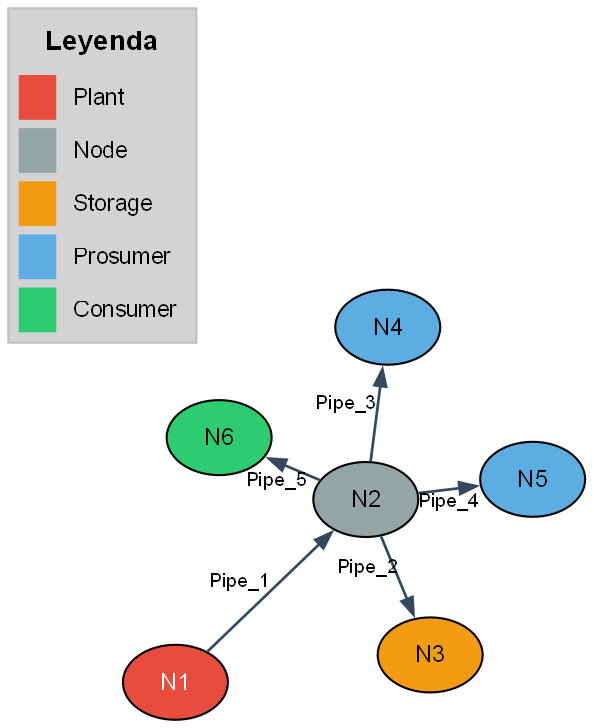

In [90]:
Image("network.png") 

In [91]:
DHN.Creation_objects()

In [92]:
input_variables={"pipe_objects":{'T_amb':[273.15,283.15,284]},
                 "Consumer":[{"Q_building_profile":[45000,35000,65000],"T_return_design": 305}],
                "Slack_Central_production":{"T_out_design":350,"P_out_design":3,"P_lift_design":0.5},
                "HP_actors":[{"mode":["COOLING_NET","COOLING_NET","COOLING_NET"],"T_cons":[[323.15,333.15],[323.15,333.15],[323.15,333.15]],"Q_consumer":[-15000,-15000,-15000],'dT_water': [10,10,10]},{"mode":["HEATING_NET","HEATING_NET","HEATING_NET"],"T_cons":[[308.15,298.15],[308.15,298.15],[308.15,298.15]],"Q_consumer":[-15000,-15000,-15000] ,'dT_water': [-10,-10,-10]}],
                "Storage_actors":[{"mass_flow":[0.85,-0.150,0.150],'T_amb':[273.15,283.15,284]}],
                "multi_plant":[{"T_out_design":[],"Q_nominal":[]}]}


In [93]:
DHN.def_input_variables_simulation(consumer_actors=DHN.Consumer_actors,slack_plant=DHN.slack_plant,
                                   input_variables=input_variables,HP_actors=DHN.HP_actors,Storage_actors=DHN.Storage_actors,
                                   multi_plant_actors=DHN.multi_plant_actors,pipe_objects=DHN.Pipe_objects)

In [94]:
T_prev={}
Dynamic_actors=DHN.Consumer_actors["Object"]+DHN.HP_actors["Object"]+DHN.Storage_actors["Object"]
for a in Dynamic_actors:
    T_prev[a.name]=random.uniform(35+273.15,60+273.15)  

In [95]:
DHN.simulate_period_time(DHN.net,consumer_actors=DHN.Consumer_actors,slack_plant=DHN.slack_plant,
                                   HP_actors=DHN.HP_actors,Storage_actors=DHN.Storage_actors,
                                   multi_plant_actors=DHN.multi_plant_actors,
                                   pipe_objects=DHN.Pipe_objects,
                                   T_prev=T_prev,print_iteration=False,n_hours=3,
                                   tol_k=1E-6,max_iter=1000,relax=0.5)
                         
        


 iter  | residual   | progress   | massflow   | pressure   | enthalpy   | fluid      | energy     | component  
-------+------------+------------+------------+------------+------------+------------+------------+------------
 1     | 9.01e+05   | 0 %        | 1.75e+00   | 1.60e+06   | 4.22e+05   | 0.00e+00   | 0.00e+00   | 0.00e+00   
 2     | 7.66e+04   | 12 %       | 1.44e+00   | 3.06e+05   | 8.87e+03   | 0.00e+00   | 0.00e+00   | 0.00e+00   
 3     | 7.49e+03   | 23 %       | 1.76e-01   | 3.80e+04   | 1.26e+03   | 0.00e+00   | 0.00e+00   | 0.00e+00   
 4     | 1.52e+01   | 53 %       | 3.35e-05   | 1.03e+03   | 3.26e+01   | 0.00e+00   | 0.00e+00   | 0.00e+00   
 5     | 9.90e-03   | 88 %       | 2.45e-08   | 6.90e-01   | 2.18e-02   | 0.00e+00   | 0.00e+00   | 0.00e+00   
 6     | 1.02e-05   | 100 %      | 1.97e-13   | 3.13e-07   | 9.14e-06   | 0.00e+00   | 0.00e+00   | 0.00e+00   
 7     | 5.39e-10   | 100 %      | 2.92e-12   | 2.67e-09   | 4.15e-07   | 0.00e+00   | 0.00e+00   | 0.0

KeyError: 'HP_N4'

In [ ]:
DHN.CO2

{'Central_plant': {0: np.float64(492700.68224671227),
  1: np.float64(81420.05694340197),
  2: np.float64(186454.20870253714)}}

In [ ]:
DHN.Cost

{'Central_plant': {0: np.float64(55428826.75275513),
  1: np.float64(9159756.406132722),
  2: np.float64(20976098.47903543)}}

In [ ]:
DHN.history

{'HP_N4': {0: np.float64(348.5682001292009),
  1: np.float64(348.2230548322237),
  2: np.float64(348.6669086380763)},
 'HP_N5': {0: np.float64(348.9954340748086),
  1: np.float64(348.58912375997215),
  2: np.float64(349.0332509375648)},
 'Storage_N3': {0: np.float64(349.23351746481404),
  1: np.float64(339.7325778739231),
  2: np.float64(347.37264889353804)}}

In [ ]:
DHN.net.res_circ_pump_pressure

,p_from_bar,p_to_bar,t_from_k,t_to_k,t_outlet_k,mdot_from_kg_per_s,mdot_to_kg_per_s,vdot_m3_per_s,deltat_k,qext_w
0,2.5,3.0,336.596167,350.0,350.0,1.410664,-1.410664,0.001443,-13.403833,79243.038699


In [ ]:
DHN.net